In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import Counter
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

# Фиксирую seed и проверяю доступность cuda
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Доступно: {device}")

# Устанавливаю гиперпараметры
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR = 1e-4
TARGET = 'type' # на этапе baseline решения фокусируюсь на type

Доступно: cuda


In [2]:
# Загружаю датасет, если он был сохранен в блоке с EDA
output_df_f = 'output/annotations.pkl'

if os.path.exists(output_df_f):
    df = pd.read_pickle(output_df_f)
    print(f"Датасет с {len(df)} значений загружен.")
else:
    print(f".pkl не найден по пути {output_df_f}.")

df_clean = df[df['floors'] <= 50].copy()

Датасет с 16113 значений загружен.


In [3]:
# Извлекаю уникальные классы и делаю энкодер
classes = sorted(df_clean[TARGET].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

In [4]:
# Выполняю разделение train, val, test
train_df, tmp_df = train_test_split(
    df_clean, test_size=0.3, stratify=df_clean[TARGET], random_state=42
)
val_df, test_df = train_test_split(
    tmp_df, test_size=0.5, stratify=tmp_df[TARGET], random_state=42
)

print(f"train: {len(train_df)}; val: {len(val_df)}; test: {len(test_df)}")

train: 11258; val: 2413; test: 2413


**Для борьбы с дисбалансом классов принимаем, что вес каждого класса обратно пропорционален его частоте в обучающей выборке.**

In [5]:
counts = df_clean[TARGET].value_counts()
num_classes = len(classes)

class_weights = torch.FloatTensor(
    [len(df_clean) / (num_classes * counts[c]) for c in classes]
).to(device)

In [6]:
class BuildingDataset(Dataset):
    """Датасет torch"""
    
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.tf = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, i):
        # Привожу к RGB во избежание ошибок
        img = Image.open(self.df.loc[i, 'filepath']).convert('RGB')
        
        # Labeling
        lbl = class_to_idx[self.df.loc[i, TARGET]]
        
        return self.tf(img) if self.tf else img, lbl

**В части аугментации делаю следуюющее:**  
**Масштабирую до 256 пикселей и случайно вырезаю квадрат 224x224;**  
**Выполняю случайное отражение по горизонтали (p=0.5);**
**Случайные искажения цвета.**  
*Примененнные способы в целом достаточно распространены и были на маголего по CV.*

In [7]:
# Нормализация для ImageNet
norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)


train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    norm
])

# Оценочные, обрезка строго по центру
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    norm
])

# Применяю трансформации выше
train_ds = BuildingDataset(train_df, train_tf)
val_ds = BuildingDataset(val_df, eval_tf)
test_ds = BuildingDataset(test_df, eval_tf)

**Дополнительно для борьбы с дисбалансом использую WeightedRandomSampler**  
*Повышает частоту попадания малочисленных классов в обучающие пакеты, отлично комбинируется с пунктом выше.*  

In [8]:
lbls = [class_to_idx[train_df.iloc[i][TARGET]] for i in range(len(train_df))]
sw = [1.0 / Counter(lbls)[l] for l in lbls]
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

In [9]:
train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=0)

In [10]:
# Преодобученная модель
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

**Для baseline решения я использую ResNet-50 обученную на ImageNet, но заменяю head на свой слой с dropout.**  

In [11]:
# Отключаю 30% нейронов и в линейном слое беру целевое число классов
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Полученное число параметров: {total_params}")

Полученное число параметров: 23528522


In [12]:
# Сильнее штрафует редкие классы
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW с L2-регуляризацией
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=LR)

# Планировщик - снижает lr в 2 раза, если точность не растет 3 эпохи к ряду
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

In [13]:
best_acc = 0.0
patience = 7
no_improve = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    tr_loss, tr_corr = 0, 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        # Обнуление градиентов, проход, потери, обратный ход, обновление весов
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        tr_loss += loss.detach().item() * x.size(0)
        tr_corr += (out.argmax(1) == y).sum().item()
    
    tr_loss /= len(train_ds)
    tr_acc = tr_corr / len(train_ds)
    
    # Валидация
    model.eval()
    val_loss, val_corr = 0, 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)
            val_corr += (out.argmax(1) == y).sum().item()
    
    val_loss /= len(val_ds)
    val_acc = val_corr / len(val_ds)
    
    # Вызов планировщика, снижать lr или нет
    scheduler.step(val_acc)
    
    print(f"Эпоха {epoch+1:2d}; train loss={tr_loss:.3f}, train acc={tr_acc:.3f}; val loss={val_loss:.3f}, val acc={val_acc:.3f}")
    # Сохраняяю лучший вариант
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_baseline.pth")
        print(f"Сохранена лучшая модель с val acc={val_acc:.3f}")
        no_improve = 0
    else:
        no_improve += 1
        
    if no_improve >= patience:
        print(f"Предел эпох без улучшения, остановка на {epoch+1}.")
        break

print(f"Обучение завершено, лучшая точность на валидации: {best_acc:.3f}.")

Эпоха  1; train loss=1.203, train acc=0.407; val loss=1.408, val acc=0.353
Сохранена лучшая модель с val acc=0.353
Эпоха  2; train loss=0.687, train acc=0.628; val loss=1.293, val acc=0.436
Сохранена лучшая модель с val acc=0.436
Эпоха  3; train loss=0.487, train acc=0.712; val loss=1.296, val acc=0.492
Сохранена лучшая модель с val acc=0.492
Эпоха  4; train loss=0.385, train acc=0.764; val loss=1.250, val acc=0.549
Сохранена лучшая модель с val acc=0.549
Эпоха  5; train loss=0.320, train acc=0.797; val loss=1.209, val acc=0.582
Сохранена лучшая модель с val acc=0.582
Эпоха  6; train loss=0.267, train acc=0.825; val loss=1.224, val acc=0.588
Сохранена лучшая модель с val acc=0.588
Эпоха  7; train loss=0.237, train acc=0.844; val loss=1.306, val acc=0.584
Эпоха  8; train loss=0.204, train acc=0.855; val loss=1.386, val acc=0.586
Эпоха  9; train loss=0.181, train acc=0.872; val loss=1.343, val acc=0.624
Сохранена лучшая модель с val acc=0.624
Эпоха 10; train loss=0.167, train acc=0.877; 

In [14]:
# Проверка на тесте
model.load_state_dict(torch.load("best_baseline.pth", weights_only=True))
model.eval()

preds, trues = [], []
with torch.no_grad():
    for x, y in test_loader:
        # индексы с макс вероятностью
        preds.extend(model(x.to(device)).argmax(1).cpu().numpy())
        trues.extend(y.numpy())

test_acc = np.mean(np.array(preds) == np.array(trues))
print(f"\nТочность на test: {test_acc:.4f} ({test_acc*100:.1f}%)")

print("\nClassification report:")
print(classification_report(trues, preds, target_names=classes, digits=3))


Точность на test: 0.7178 (71.8%)

Classification report:
              precision    recall  f1-score   support

  apartments      0.857     0.733     0.790       769
   education      0.455     0.508     0.480       130
      garage      0.784     0.707     0.744        41
       hotel      0.576     0.642     0.607       106
       house      0.708     0.840     0.768       324
  industrial      0.651     0.629     0.640       175
      office      0.714     0.748     0.731       377
      public      0.634     0.563     0.597       126
   religious      0.786     0.810     0.798       100
      retail      0.647     0.713     0.679       265

    accuracy                          0.718      2413
   macro avg      0.681     0.689     0.683      2413
weighted avg      0.727     0.718     0.720      2413



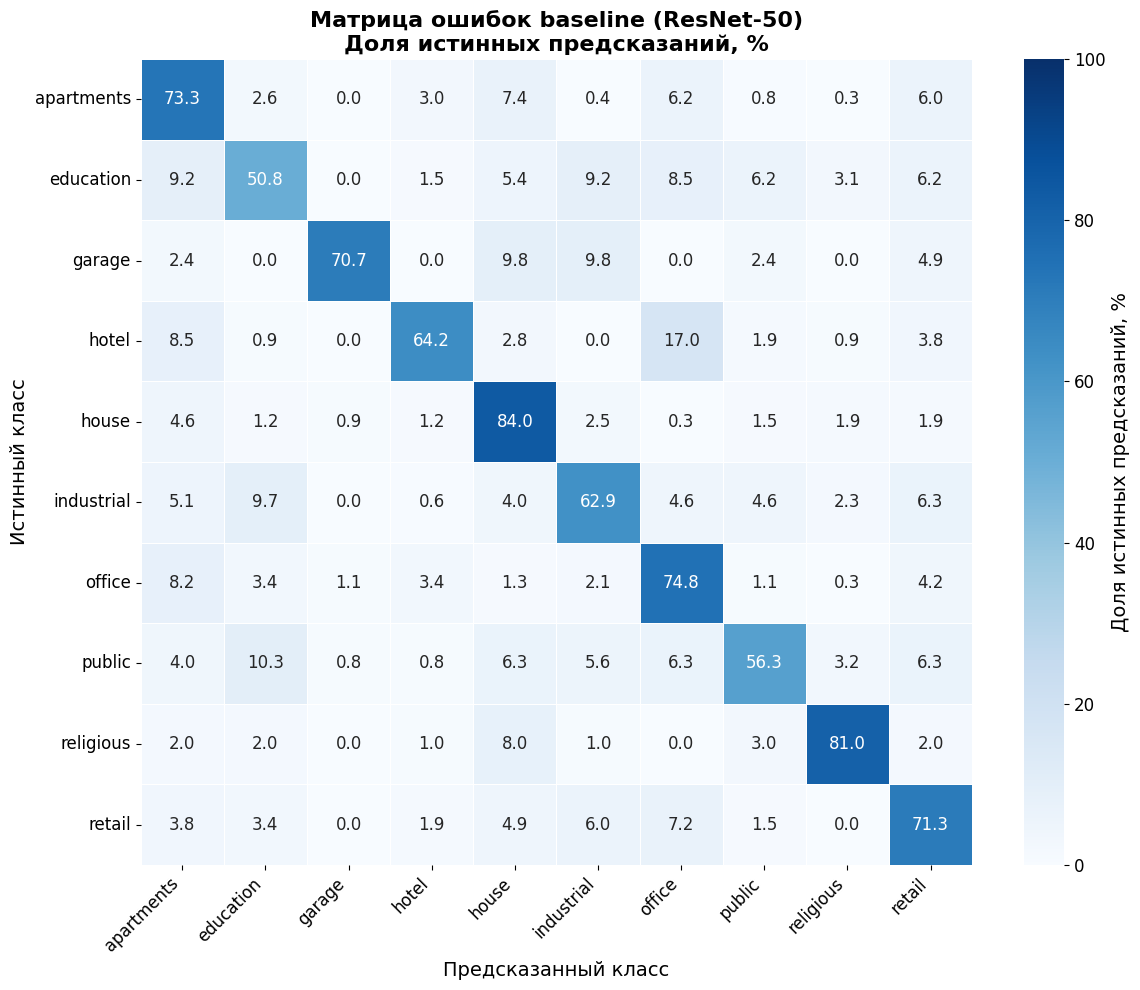

In [28]:
cm = confusion_matrix(trues, preds)

# В каждой ячейке считаю % от истинного класса
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1f',
    cmap='Blues',
    xticklabels=classes, 
    yticklabels=classes,
    linewidths=0.5, 
    cbar_kws={'label': 'Доля истинных предсказаний, %'},
    vmin=0, 
    vmax=100,
    annot_kws={'fontsize': 12}
)

# Ну уж выдеру его так, чего уж
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Доля истинных предсказаний, %', fontsize=14) 

plt.title('Матрица ошибок baseline (ResNet-50)\nДоля истинных предсказаний, %', 
          fontweight='bold', fontsize=16)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.ylabel('Истинный класс', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

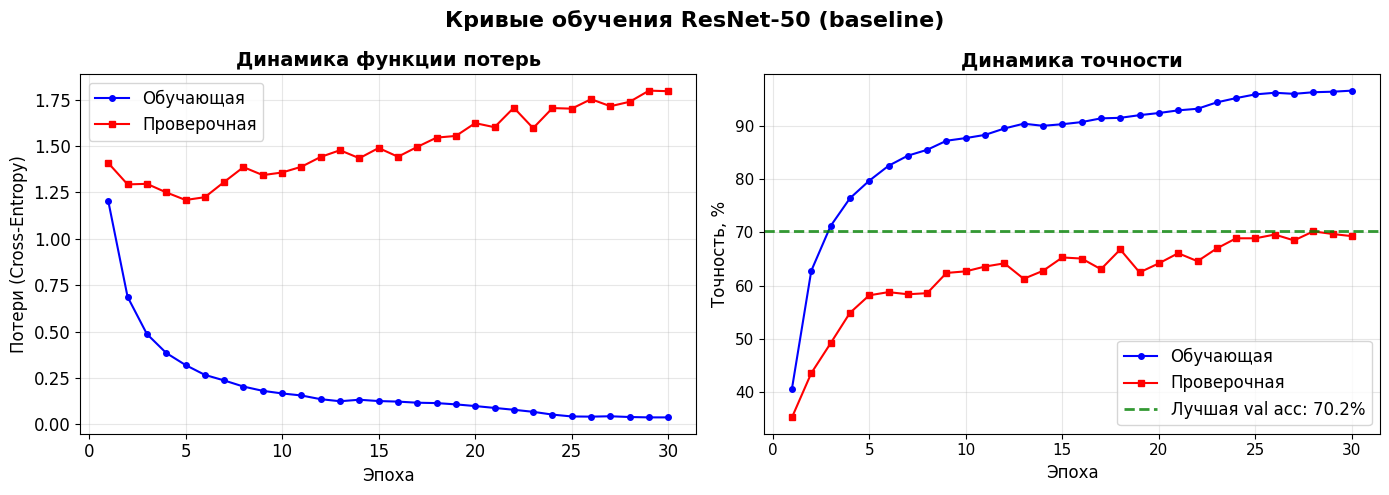

In [30]:
# Выписал руками, тк не заводил словарик для истории обучения по эпохам
epochs_baseline = list(range(1, 31))
train_loss_baseline = [1.203, 0.687, 0.487, 0.385, 0.320, 0.267, 0.237, 0.204, 0.181, 0.167,
                       0.156, 0.136, 0.125, 0.133, 0.126, 0.123, 0.117, 0.115, 0.108, 0.099,
                       0.089, 0.079, 0.068, 0.053, 0.043, 0.042, 0.044, 0.040, 0.038, 0.038]
val_loss_baseline = [1.408, 1.293, 1.296, 1.250, 1.209, 1.224, 1.306, 1.386, 1.343, 1.357,
                     1.388, 1.441, 1.477, 1.434, 1.489, 1.442, 1.495, 1.545, 1.554, 1.623,
                     1.601, 1.706, 1.596, 1.704, 1.701, 1.752, 1.714, 1.738, 1.798, 1.795]
train_acc_baseline = [0.407, 0.628, 0.712, 0.764, 0.797, 0.825, 0.844, 0.855, 0.872, 0.877,
                      0.883, 0.895, 0.904, 0.900, 0.903, 0.907, 0.914, 0.915, 0.920, 0.924,
                      0.929, 0.932, 0.944, 0.952, 0.959, 0.962, 0.960, 0.963, 0.964, 0.966]
val_acc_baseline = [0.353, 0.436, 0.492, 0.549, 0.582, 0.588, 0.584, 0.586, 0.624, 0.627,
                    0.636, 0.642, 0.613, 0.628, 0.653, 0.651, 0.631, 0.668, 0.625, 0.642,
                    0.661, 0.646, 0.670, 0.689, 0.689, 0.696, 0.685, 0.702, 0.697, 0.693]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Потери
ax1.plot(epochs_baseline, train_loss_baseline, 'b-o', label='Обучающая', markersize=4, linewidth=1.5)
ax1.plot(epochs_baseline, val_loss_baseline, 'r-s', label='Проверочная', markersize=4, linewidth=1.5)
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Потери (Cross-Entropy)', fontsize=12)
ax1.set_title('Динамика функции потерь', fontweight='bold', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3)
ax1.tick_params(axis='both', labelsize=12)

# Точность
ax2.plot(epochs_baseline, [a*100 for a in train_acc_baseline], 'b-o', label='Обучающая', markersize=4, linewidth=1.5)
ax2.plot(epochs_baseline, [a*100 for a in val_acc_baseline], 'r-s', label='Проверочная', markersize=4, linewidth=1.5)
ax2.axhline(y=70.2, color='green', linestyle='--', linewidth=2, alpha=0.8, label='Лучшая val acc: 70.2%')
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Точность, %', fontsize=12)
ax2.set_title('Динамика точности', fontweight='bold', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)
ax2.tick_params(axis='both', labelsize=11)

plt.suptitle('Кривые обучения ResNet-50 (baseline)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()